# Tile Registration Workbook - Raw & Normalized
### Monje Lab - horizontal pair registration comparison

Two-part evaluation: **Part 1** runs all four steps with raw pixel values; **Part 2** repeats with Z-score normalized values.

MSE window geometry:
- **Width**: left edge of img_b on canvas to right edge of img_a on canvas
- **Height (dy-aware)**:
  - `dy > 0`: img_b is below img_a -> rows from **top of A** to **bottom of B**
  - `dy < 0`: img_b is above img_a -> rows from **top of B** to **bottom of A**
  - `dy = 0`: symmetric

| Step | Description |
|------|-------------|
| 0 | **Naive** - fixed 20% overlap, no shift correction |
| 1 | **PCC (full frames)** - skimage PCC on full images |
| 2 | **PCC (overlap strips)** - PCC on overlap strips only |
| 3 | **PCC (masked overlap)** - Otsu-thresholded mask then PCC on foreground pixels |

In [138]:
# -- Imports -------------------------------------------------------
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import tifffile
from pathlib import Path
from skimage.registration import phase_cross_correlation
from skimage.filters import threshold_otsu

matplotlib.rcParams['figure.dpi'] = 120


In [139]:
# -- Helper functions -----------------------------------------------

def load_tile(path):
    img = tifffile.imread(str(path)).astype('float32')
    while img.ndim > 2:
        img = img[0]
    return img


def norm_disp(img):
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo + 1e-9)


def run_pcc(ref, mov, upsample=20):
    if ref.shape != mov.shape:
        r = min(ref.shape[0], mov.shape[0])
        c = min(ref.shape[1], mov.shape[1])
        ref, mov = ref[:r, :c], mov[:r, :c]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        shift, error, _ = phase_cross_correlation(
            ref, mov, upsample_factor=upsample, normalization=None)
    return float(shift[0]), float(shift[1]), float(error)


def sinusoidal_blend(strip_a, strip_b):
    n = strip_a.shape[1]
    t = np.linspace(0.0, 1.0, n, dtype='float32')
    w = 0.5 * (1.0 + np.cos(np.pi * t))
    ramp = np.broadcast_to(w, strip_a.shape).copy()
    ramp[strip_a == 0] = 0.0
    ramp[strip_b == 0] = 1.0
    return ramp * strip_a + (1.0 - ramp) * strip_b


def stitch_horizontal(img_a, img_b, overlap_px):
    ha, hb = img_a.shape[0], img_b.shape[0]
    target_h = max(ha, hb)
    if ha < target_h:
        img_a = np.pad(img_a, ((0, target_h - ha), (0, 0)))
    if hb < target_h:
        img_b = np.pad(img_b, ((0, target_h - hb), (0, 0)))
    overlap_px = max(1, min(overlap_px, img_a.shape[1], img_b.shape[1]))
    body_a  = img_a[:,  :-overlap_px]
    strip_a = img_a[:,  -overlap_px:]
    strip_b = img_b[:,  :overlap_px]
    body_b  = img_b[:,  overlap_px:]
    blended = sinusoidal_blend(strip_a, strip_b)
    return np.concatenate([body_a, blended, body_b], axis=1)


def overlay_rgy(img_a, img_b, overlap_px, dy=0.0, dx=0.0, title=''):
    idy = int(round(dy))
    idx = int(round(dx))
    h_a, w_a = img_a.shape
    h_b, w_b = img_b.shape
    b_x0 = w_a - overlap_px + idx
    b_y0 = idy
    canvas_h = max(h_a, b_y0 + h_b, 1) + abs(idy)
    canvas_w = max(w_a, b_x0 + w_b, 1)
    canvas_h = max(canvas_h, 1); canvas_w = max(canvas_w, 1)
    ch_a = np.zeros((canvas_h, canvas_w), dtype='float32')
    ch_b = np.zeros((canvas_h, canvas_w), dtype='float32')
    ch_a[:h_a, :w_a] = norm_disp(img_a)
    by0 = max(0, b_y0); by0_src = max(0, -b_y0)
    bx0 = max(0, b_x0); bx0_src = max(0, -b_x0)
    h_clip = min(h_b - by0_src, canvas_h - by0)
    w_clip = min(w_b - bx0_src, canvas_w - bx0)
    if h_clip > 0 and w_clip > 0:
        ch_b[by0:by0+h_clip, bx0:bx0+w_clip] = \
            norm_disp(img_b[by0_src:by0_src+h_clip, bx0_src:bx0_src+w_clip])
    rgb = np.stack([ch_a, ch_b, np.zeros_like(ch_a)], axis=-1)
    fig, ax = plt.subplots(figsize=(min(14, canvas_w // 100 + 4), 5))
    ax.imshow(rgb, aspect='auto')
    ax.axvline(w_a - 1, color='cyan',    lw=0.8, linestyle='--', alpha=0.6,
               label=f'A right edge (x={w_a-1})')
    ax.axvline(b_x0,    color='magenta', lw=0.8, linestyle='--', alpha=0.6,
               label=f'B left edge (x={b_x0})')
    pr = mpatches.Patch(color=(1,0,0), label='Tile A only')
    pg = mpatches.Patch(color=(0,1,0), label='Tile B only')
    py = mpatches.Patch(color=(1,1,0), label='Overlap (both)')
    ax.legend(handles=[pr, pg, py], loc='upper right', fontsize=7, framealpha=0.6)
    ax.set_title(f'{title}  |  dy={dy:+.1f}  dx={dx:+.1f}  overlap={overlap_px}px', fontsize=9)
    ax.axis('off'); plt.tight_layout(); plt.show()
    print(f'  Shift: dy={dy:+.2f}, dx={dx:+.2f}')


def normalize_tile(img):
    mu, sig = img.mean(), img.std()
    if sig < 1e-9:
        return np.zeros_like(img)
    return ((img - mu) / sig).astype('float32')


def otsu_fg_mask(patch, multiplier):
    return patch > multiplier * threshold_otsu(patch)


def mutual_information(patch_a, patch_b, mask, bins=64):
    """Mutual information (nats) between two patches over the given mask."""
    if mask.sum() < 2:
        return float('nan')
    a = patch_a[mask].astype('float64')
    b = patch_b[mask].astype('float64')
    def to_bins(x):
        lo, hi = x.min(), x.max()
        if hi <= lo:
            return np.zeros(len(x), dtype=int)
        return np.clip(((x - lo) / (hi - lo) * bins).astype(int), 0, bins - 1)
    joint, _, _ = np.histogram2d(to_bins(a), to_bins(b),
                                  bins=bins, range=[[0, bins], [0, bins]])
    pxy = joint / (joint.sum() + 1e-12)
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    nz = pxy > 0
    return float(np.sum(pxy[nz] * np.log(pxy[nz] / ((px * py)[nz] + 1e-12))))


def masked_mse(patch_a, patch_b, raw_a, raw_b, multiplier):
    # OR mask: include every pixel where at least one tile has foreground signal.
    # This correctly penalises overhangs (A has tissue, B has background → large
    # diff) so a misaligned naive baseline scores high MSE even with a big overhang.
    mask = otsu_fg_mask(raw_a, multiplier) | otsu_fg_mask(raw_b, multiplier)
    if mask.sum() == 0:
        return float('nan'), 0, float('nan')
    diff = patch_a[mask].astype('float64') - patch_b[mask].astype('float64')
    mse = float(np.mean(diff ** 2))
    mi  = mutual_information(patch_a, patch_b, mask)
    return mse, int(mask.sum()), mi


def compute_mse_patches(img_a_eval, img_b_eval, img_a_raw, img_b_raw,
                        overlap_px_naive, overlap_px_pcc, dy, dx, otsu_multiplier):
    # MSE window geometry
    # Width:  left edge of img_b on canvas --> right edge of img_a on canvas
    # Height (dy-aware, ALIGNED rows only — both tiles must physically exist):
    #   dy >= 0: B placed at canvas row +idy  ->  A[idy:h_a]  vs  B[0:h_a-idy]
    #   dy <  0: B placed at canvas row  idy  ->  A[0:h_a+idy] vs  B[-idy:h_b]
    h_a, w_a = img_a_eval.shape
    h_b, w_b = img_b_eval.shape
    idy = int(round(dy))
    idx = int(round(dx))

    # Step 0 (Naive): 20% overlap, dy=0 dx=0
    ns = w_a - overlap_px_naive
    patch_a0 = img_a_eval[0:h_a, ns:w_a]
    patch_b0 = img_b_eval[0:h_a, 0:overlap_px_naive]
    raw_a0   = img_a_raw [0:h_a, ns:w_a]
    raw_b0   = img_b_raw [0:h_a, 0:overlap_px_naive]
    mse0, nfg0, mi0 = masked_mse(patch_a0, patch_b0, raw_a0, raw_b0, otsu_multiplier)

    # Step 3 (Masked PCC): physically overlapping region with correct row alignment
    b_x0_3 = w_a - overlap_px_pcc + idx
    col_a0 = b_x0_3;  col_a1 = w_a
    col_b0 = 0;        col_b1 = w_a - b_x0_3
    if col_b1 <= 0 or col_a0 >= w_a:
        raise ValueError(f'img_b left edge {b_x0_3} does not overlap img_a right edge {w_a}')
    col_a0 = max(0, col_a0); col_b1 = min(w_b, col_b1)
    col_w  = min(col_a1 - col_a0, col_b1 - col_b0)

    # Aligned rows: only canvas rows where BOTH tiles exist
    if idy >= 0:
        # B placed at canvas row +idy; B row 0 aligns with A row idy
        row_a0 = idy
        row_b0 = 0
        row_h  = min(h_a - idy, h_b)
    else:
        # B placed at canvas row idy (negative); A row 0 aligns with B row -idy
        row_a0 = 0
        row_b0 = -idy
        row_h  = min(h_a, h_b + idy)

    row_a1 = row_a0 + row_h
    row_b1 = row_b0 + row_h

    if row_h <= 0:
        raise ValueError(f'No row overlap: dy={dy}, h_a={h_a}, h_b={h_b}')

    patch_a3 = img_a_eval[row_a0:row_a1, col_a0:col_a0+col_w]
    patch_b3 = img_b_eval[row_b0:row_b1, col_b0:col_b0+col_w]
    raw_a3   = img_a_raw [row_a0:row_a1, col_a0:col_a0+col_w]
    raw_b3   = img_b_raw [row_b0:row_b1, col_b0:col_b0+col_w]
    assert patch_a3.shape == patch_b3.shape
    mse3, nfg3, mi3 = masked_mse(patch_a3, patch_b3, raw_a3, raw_b3, otsu_multiplier)

    return dict(
        patch_a0=patch_a0, patch_b0=patch_b0, mse0=mse0, nfg0=nfg0, mi0=mi0,
        rs0=0, re0=h_a, cs0=ns, ce0=w_a,
        patch_a3=patch_a3, patch_b3=patch_b3, mse3=mse3, nfg3=nfg3, mi3=mi3,
        rs3=row_a0, re3=row_a1, cs3=col_a0, ce3=col_a0+col_w,
        col_w=col_w,
    )


def print_mse_table(res, dy, otsu_multiplier, label=''):
    pct_mse = 100.0 * (res['mse3'] - res['mse0']) / res['mse0']
    pct_mi  = 100.0 * (res['mi3']  - res['mi0'])  / res['mi0'] if res['mi0'] else float('nan')
    direction_mse = 'improvement' if pct_mse < 0 else 'degradation'
    direction_mi  = 'improvement' if pct_mi  > 0 else 'degradation'
    print('─' * 80)
    if label: print(f'  {label}')
    print(f"  Step 0 strip : cols [{res['cs0']}:{res['ce0']}]  rows [{res['rs0']}:{res['re0']}]")
    print(f"  Step 3 strip : cols [{res['cs3']}:{res['ce3']}]  rows [{res['rs3']}:{res['re3']}]  "
          f"({res['col_w']} px wide, dy={dy:+.2f})")
    print(f'  Otsu multiplier : {otsu_multiplier}  |  OR foreground mask')
    print()
    print(f"  {'Method':<25} {'Patch shape':>15} {'FG pixels':>12} {'MSE':>14} {'MI (nats)':>12}")
    print(f"  {'-'*80}")
    print(f"  {'Step 0 - Naive':<25} {str(res['patch_a0'].shape):>15} {res['nfg0']:>12,} {res['mse0']:>14.4f} {res['mi0']:>12.4f}")
    print(f"  {'Step 3 - Masked PCC':<25} {str(res['patch_a3'].shape):>15} {res['nfg3']:>12,} {res['mse3']:>14.4f} {res['mi3']:>12.4f}")
    print(f"  {'-'*80}")
    print(f'  MSE % change (Step 3 vs Step 0): {pct_mse:+.1f}%  ({direction_mse})')
    print(f'  MI  % change (Step 3 vs Step 0): {pct_mi:+.1f}%  ({direction_mi})')
    print()


def visualise_mse_region(img_a, img_b, img_a_raw, img_b_raw,
                         overlap_px, dy, dx,
                         row_start, row_end, col_start, col_end,
                         mse, n_fg, otsu_multiplier, title):
    idy = int(round(dy)); idx = int(round(dx))
    h_a, w_a = img_a.shape; h_b, w_b = img_b.shape
    b_x0 = w_a - overlap_px + idx; b_y0 = idy
    canvas_h = max(h_a, b_y0 + h_b, 1) + abs(idy)
    canvas_w = max(w_a, b_x0 + w_b, 1)
    canvas_h = max(canvas_h, 1); canvas_w = max(canvas_w, 1)
    ch_a = np.zeros((canvas_h, canvas_w), dtype='float32')
    ch_b = np.zeros((canvas_h, canvas_w), dtype='float32')
    ch_a[:h_a, :w_a] = norm_disp(img_a)
    by0 = max(0, b_y0); by0_src = max(0, -b_y0)
    bx0 = max(0, b_x0); bx0_src = max(0, -b_x0)
    h_clip = min(h_b - by0_src, canvas_h - by0)
    w_clip = min(w_b - bx0_src, canvas_w - bx0)
    if h_clip > 0 and w_clip > 0:
        ch_b[by0:by0+h_clip, bx0:bx0+w_clip] = \
            norm_disp(img_b[by0_src:by0_src+h_clip, bx0_src:bx0_src+w_clip])
    rgb = np.stack([ch_a, ch_b, np.zeros_like(ch_a)], axis=-1)
    # Black out background pixels inside MSE box (OR mask for display)
    rh = row_end - row_start; cw_box = col_end - col_start
    bc0 = col_start - b_x0; bc1 = col_end - b_x0
    br0 = row_start - idy;  br1 = br0 + rh
    bc0 = max(0, bc0); bc1 = min(w_b, bc1)
    br0 = max(0, br0); br1 = min(h_b, br1)
    rh2 = min(rh, br1 - br0); cw2 = min(cw_box, bc1 - bc0)
    ra_crop = img_a_raw[row_start:row_start+rh2, col_start:col_start+cw2]
    rb_crop = img_b_raw[br0:br0+rh2, bc0:bc0+cw2]
    fg = otsu_fg_mask(ra_crop, otsu_multiplier) | otsu_fg_mask(rb_crop, otsu_multiplier)
    bgm = np.zeros((canvas_h, canvas_w), dtype=bool)
    bgm[row_start:row_start+rh2, col_start:col_start+cw2] = ~fg
    for c in range(3): rgb[:, :, c][bgm] = 0.0
    fig, ax = plt.subplots(figsize=(min(14, canvas_w // 100 + 4), 5))
    ax.imshow(rgb, aspect='auto')
    rect = Rectangle((col_start, row_start), col_end-col_start, row_end-row_start,
                     linewidth=2, edgecolor='cyan', facecolor='none',
                     label=f'MSE region ({col_end-col_start}x{row_end-row_start} px)')
    ax.add_patch(rect)
    ax.axvline(w_a-1, color='cyan',    lw=0.8, linestyle='--', alpha=0.4)
    ax.axvline(b_x0,  color='magenta', lw=0.8, linestyle='--', alpha=0.4)
    pr = mpatches.Patch(color=(1,0,0), label='Tile A only')
    pg = mpatches.Patch(color=(0,1,0), label='Tile B only')
    py = mpatches.Patch(color=(1,1,0), label='Overlap (both)')
    pw = mpatches.Patch(color=(1,1,1), label=f'Foreground pixels ({n_fg:,})')
    ax.legend(handles=[pr, pg, py, rect, pw], loc='upper right', fontsize=7, framealpha=0.6)
    ax.set_title(f'{title}  |  MSE={mse:.4f}  |  fg={n_fg:,}  |  '
                 f'rows [{row_start}:{row_end}]  cols [{col_start}:{col_end}]', fontsize=9)
    ax.axis('off'); plt.tight_layout(); plt.show()


In [140]:
# -- User Inputs ---------------------------------------------------
# Paths to the two horizontally adjacent tiles (A = left, B = right)

# Test Case 0 
# TILE_A_PATH = "/Users/spaltahill/test_images/260128_UltraII_5300148-2R_AF_HNACy3_cfos_2x_thickness3d5_width60_20ol_10umstep[00 x 00]_C00_z0192.ome.tif"
# TILE_B_PATH = "/Users/spaltahill/test_images/260128_UltraII_5300148-2R_AF_HNACy3_cfos_2x_thickness3d5_width60_20ol_10umstep[00 x 01]_C00_z0192.ome.tif"

# Test Case 1
# TILE_A_PATH = "/Users/spaltahill/test_images/260128_UltraII_5300148-2R_AF_HNACy3_cfos_2x_thickness3d5_width60_20ol_10umstep[00 x 01]_C00_z0192.ome.tif"
# TILE_B_PATH = "/Users/spaltahill/test_images/260128_UltraII_5300148-2R_AF_HNACy3_cfos_2x_thickness3d5_width60_20ol_10umstep[00 x 02]_C00_z0192.ome.tif"

## Test Case 2
# TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 00]_C00_z0198.ome.tif"
# TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 01]_C00_z0198.ome.tif"

## Test Case 3
# TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[02 x 01]_C00_z0198.ome.tif"
# TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[02 x 02]_C00_z0198.ome.tif"

## Test Case 4
# TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 01]_C00_z0100.ome.tif"
# TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 02]_C00_z0100.ome.tif"

## Test Case 5
# TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[03 x 01]_C00_z0100.ome.tif"
# TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[03 x 02]_C00_z0100.ome.tif"

## Test Case 6
TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[00 x 00]_C00_z0198.ome.tif"
TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[00 x 01]_C00_z0198.ome.tif"

OVERLAP_FRAC_NAIVE = 0.20   # Step 0: fixed assumed overlap
OVERLAP_FRAC_PCC   = 0.50   # Steps 1-3: wider strip for PCC registration
OTSU_MULTIPLIER    = 0.5    # < 1 permissive, > 1 strict foreground
UPSAMPLE           = 20     # PCC upsample factor


Tile A shape : (2560, 2160)  dtype=float32
Tile B shape : (2560, 2160)  dtype=float32
Naive overlap : 432 px  (20% of 2160)
PCC overlap   : 1080 px  (50% of 2160)


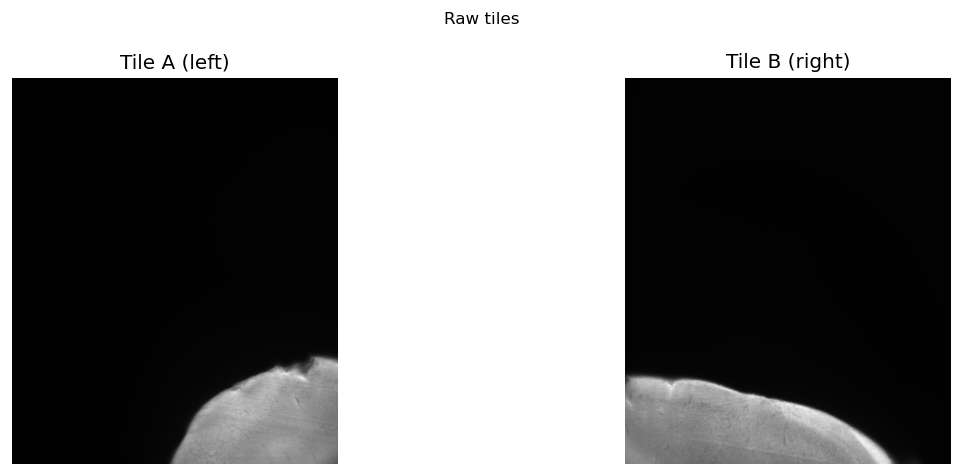

img_a_norm  mean=-0.0000  std=1.0000
img_b_norm  mean=0.0000  std=1.0000


In [141]:
# -- Load tiles ----------------------------------------------------
img_a = load_tile(TILE_A_PATH)
img_b = load_tile(TILE_B_PATH)

overlap_px_naive = int(round(OVERLAP_FRAC_NAIVE * img_a.shape[1]))
overlap_px_pcc   = int(round(OVERLAP_FRAC_PCC   * img_a.shape[1]))

print(f'Tile A shape : {img_a.shape}  dtype={img_a.dtype}')
print(f'Tile B shape : {img_b.shape}  dtype={img_b.dtype}')
print(f'Naive overlap : {overlap_px_naive} px  ({OVERLAP_FRAC_NAIVE*100:.0f}% of {img_a.shape[1]})')
print(f'PCC overlap   : {overlap_px_pcc} px  ({OVERLAP_FRAC_PCC*100:.0f}% of {img_a.shape[1]})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(norm_disp(img_a), cmap='gray'); axes[0].set_title('Tile A (left)');  axes[0].axis('off')
axes[1].imshow(norm_disp(img_b), cmap='gray'); axes[1].set_title('Tile B (right)'); axes[1].axis('off')
plt.suptitle('Raw tiles', fontsize=10); plt.tight_layout(); plt.show()

# Pre-compute normalized tiles for Part 2
img_a_norm = normalize_tile(img_a)
img_b_norm = normalize_tile(img_b)
print(f'img_a_norm  mean={img_a_norm.mean():.4f}  std={img_a_norm.std():.4f}')
print(f'img_b_norm  mean={img_b_norm.mean():.4f}  std={img_b_norm.std():.4f}')


---
## Part 1 - Raw Pixel Values
PCC and MSE computed directly on un-normalized intensities.

### Step 0 - Naive stitch (no registration) [RAW]

Stitched canvas: (2560, 3888)


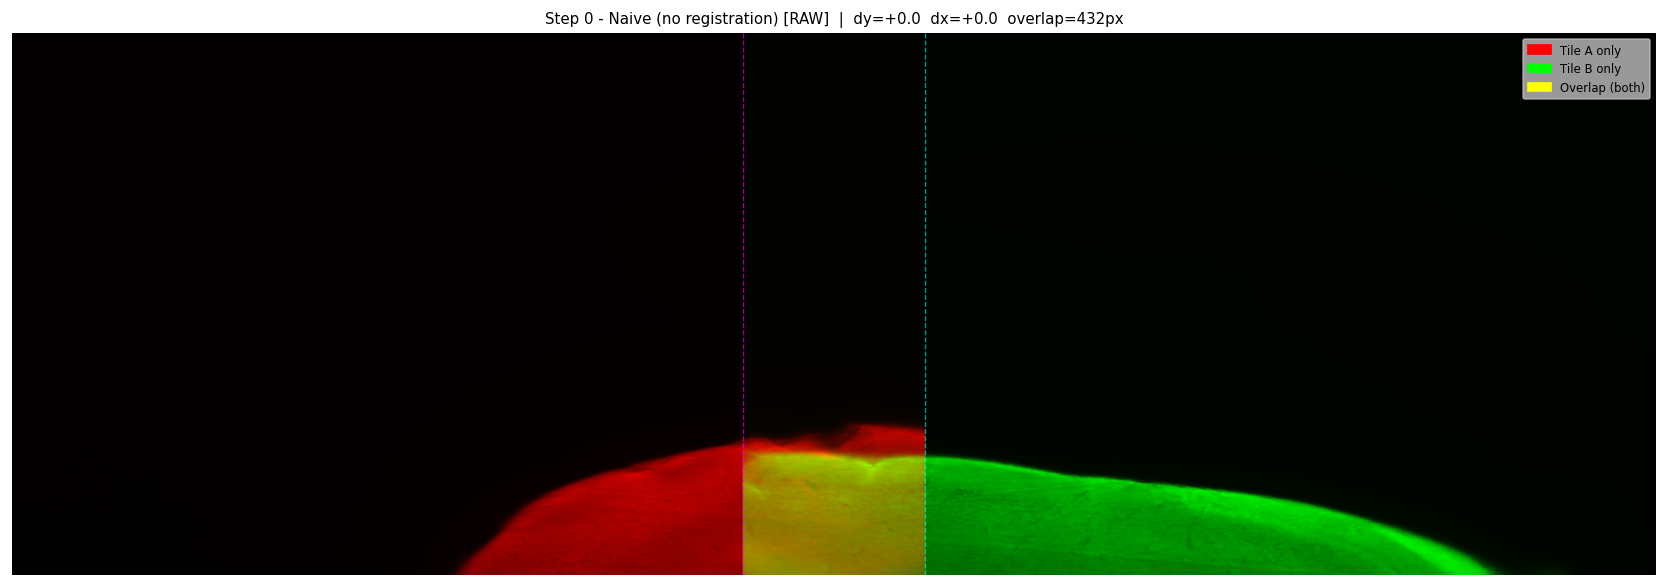

  Shift: dy=+0.00, dx=+0.00


In [142]:
# -- Step 0 (RAW): Naive stitch ----------------------------------
result_naive = stitch_horizontal(img_a, img_b, overlap_px_naive)
print(f'Stitched canvas: {result_naive.shape}')
overlay_rgy(img_a, img_b, overlap_px_naive, dy=0.0, dx=0.0,
            title='Step 0 - Naive (no registration) [RAW]')


### Step 1 - PCC on full raw frames [RAW]

Full-frame PCC (RAW)  -->  dy=+0.00  dx=-1049.10  error=nan


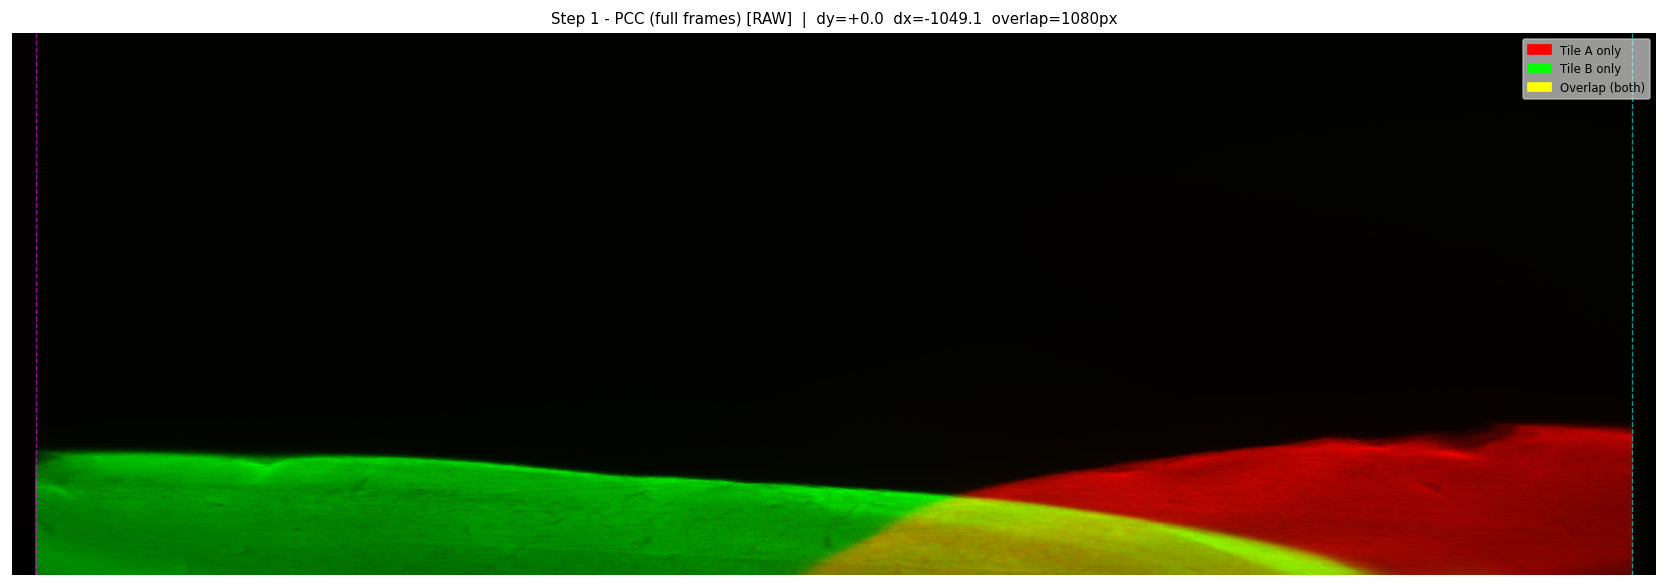

  Shift: dy=+0.00, dx=-1049.10


In [143]:
# -- Step 1 (RAW): PCC on full frames -----------------------------
dy1raw, dx1raw, err1raw = run_pcc(img_a, img_b, upsample=UPSAMPLE)
print(f'Full-frame PCC (RAW)  -->  dy={dy1raw:+.2f}  dx={dx1raw:+.2f}  error={err1raw:.4f}')
overlay_rgy(img_a, img_b, overlap_px_pcc, dy=dy1raw, dx=dx1raw,
            title='Step 1 - PCC (full frames) [RAW]')


### Step 2 - PCC on raw overlap strips [RAW]

Overlap-strip PCC (RAW)  -->  dy=-0.20  dx=+400.95  error=nan


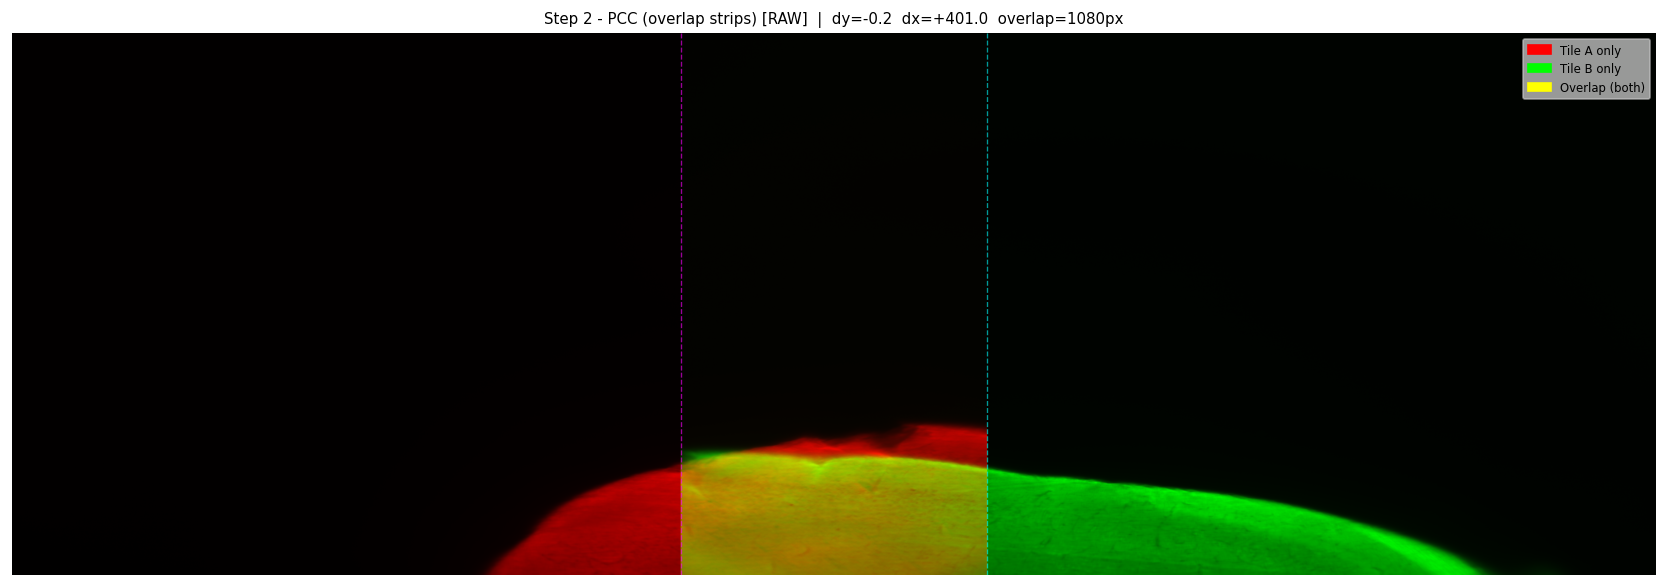

  Shift: dy=-0.20, dx=+400.95


In [144]:
# -- Step 2 (RAW): PCC on overlap strips --------------------------
strip_a2raw = img_a[:, -overlap_px_pcc:]
strip_b2raw = img_b[:,  :overlap_px_pcc]
dy2raw, dx2raw, err2raw = run_pcc(strip_a2raw, strip_b2raw, upsample=UPSAMPLE)
print(f'Overlap-strip PCC (RAW)  -->  dy={dy2raw:+.2f}  dx={dx2raw:+.2f}  error={err2raw:.4f}')
overlay_rgy(img_a, img_b, overlap_px_pcc, dy=dy2raw, dx=dx2raw,
            title='Step 2 - PCC (overlap strips) [RAW]')


### Step 3 - PCC on Otsu-masked overlap strips [RAW]

Otsu thresholds and PCC both use raw pixel values.

Otsu(A strip) = 7775.51  -->  threshold = 3887.75
Otsu(B strip) = 6301.40  -->  threshold = 3150.70
Foreground coverage: A=21.2%  B=20.7%


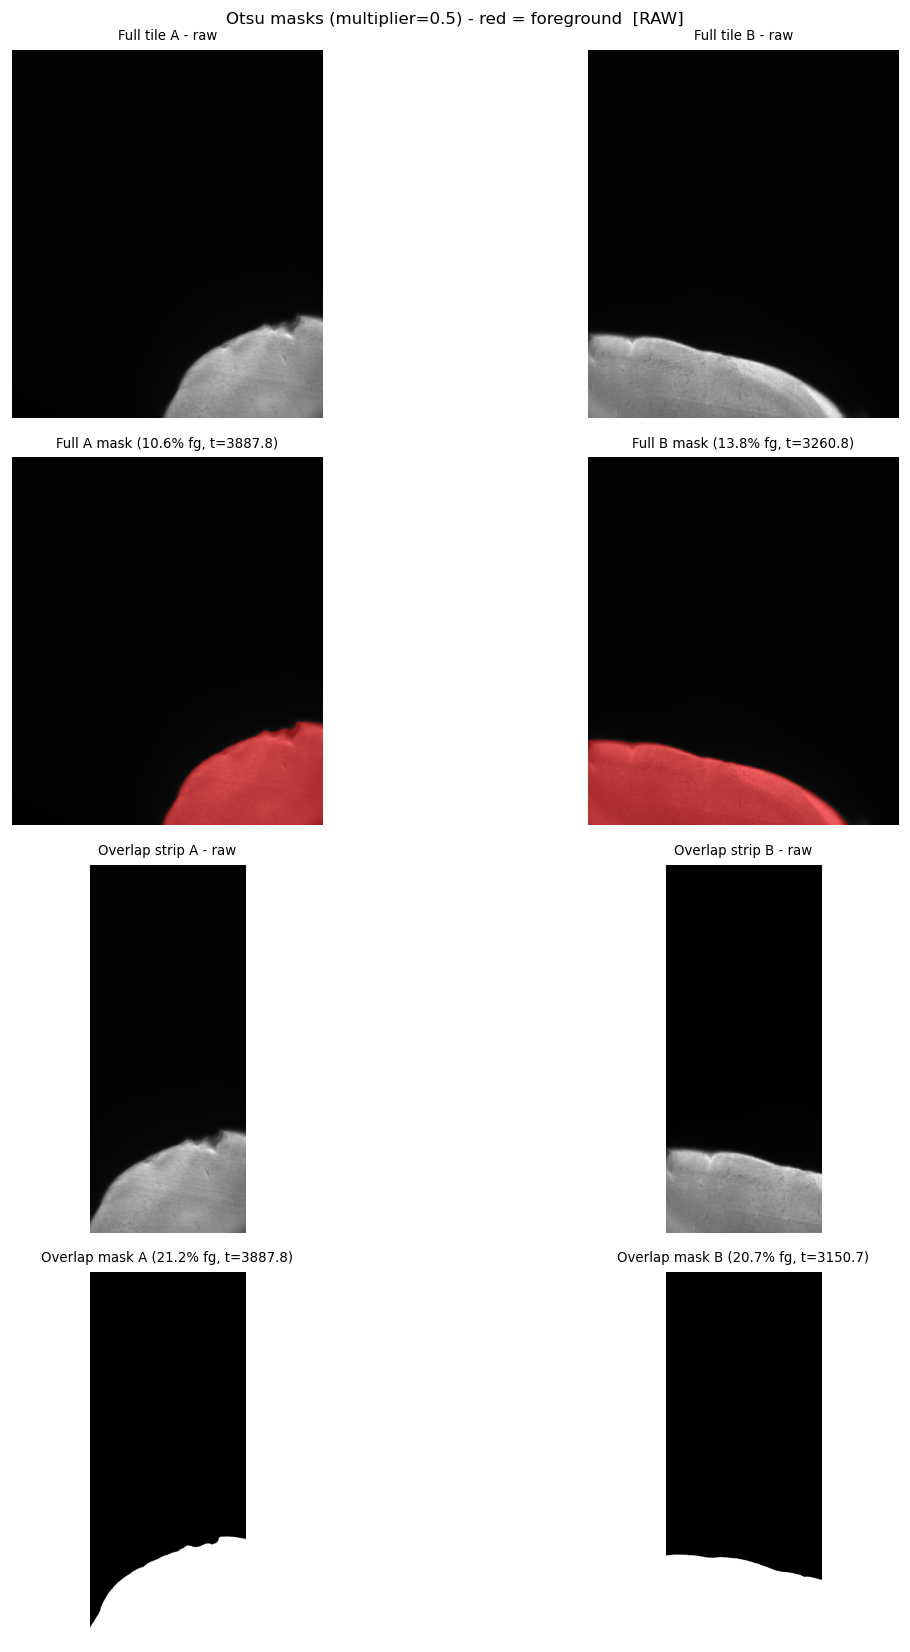

Masked PCC (RAW)  -->  dy=-118.00  dx=+890.00  error=nan


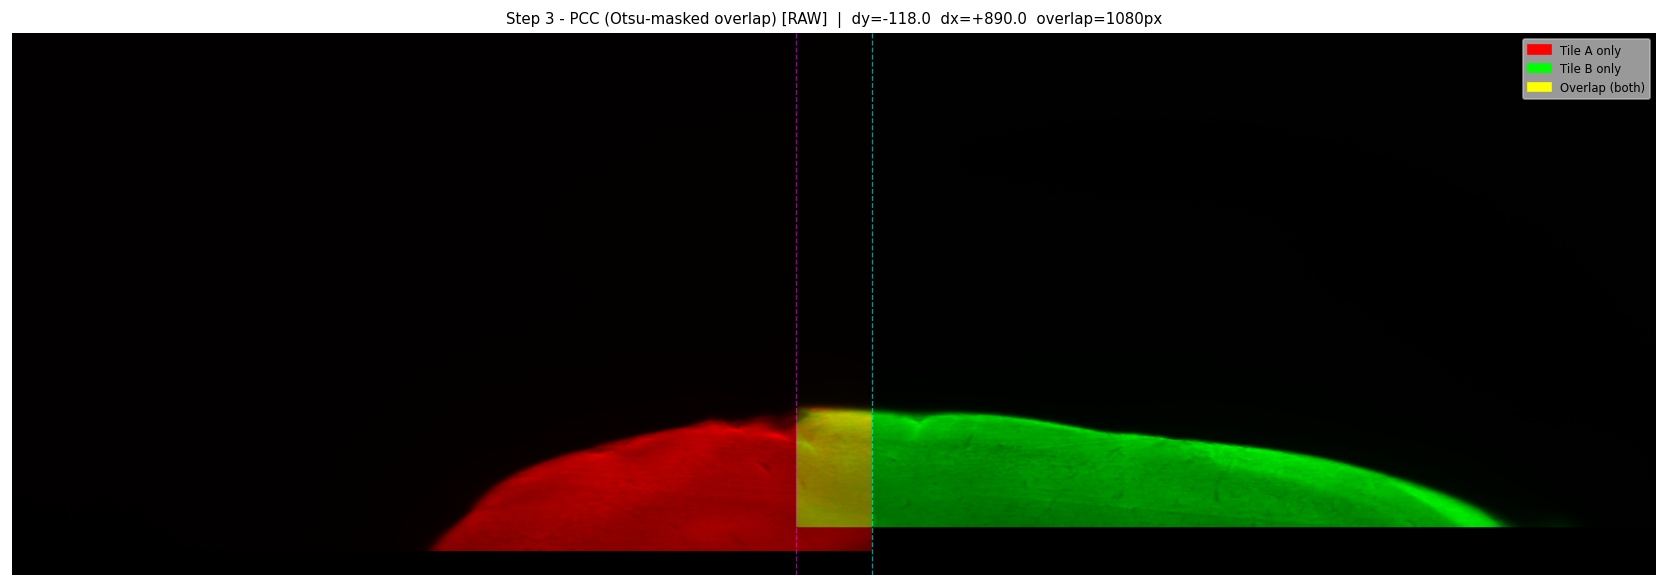

  Shift: dy=-118.00, dx=+890.00


In [145]:
# -- Step 3 (RAW): Otsu-masked PCC --------------------------------
sa3raw = img_a[:, -overlap_px_pcc:].copy()
sb3raw = img_b[:,  :overlap_px_pcc].copy()
sa3rraw = img_a[:, -overlap_px_pcc:].copy()
sb3rraw = img_b[:,  :overlap_px_pcc].copy()

oaraw = threshold_otsu(sa3rraw); obraw = threshold_otsu(sb3rraw)
taraw = OTSU_MULTIPLIER * oaraw;  tbraw = OTSU_MULTIPLIER * obraw
print(f'Otsu(A strip) = {oaraw:.2f}  -->  threshold = {taraw:.2f}')
print(f'Otsu(B strip) = {obraw:.2f}  -->  threshold = {tbraw:.2f}')

ma3raw = sa3rraw > taraw
mb3raw = sb3rraw > tbraw
print(f'Foreground coverage: A={100*ma3raw.mean():.1f}%  B={100*mb3raw.mean():.1f}%')

def make_mask_overlay(img, mask):
    g = norm_disp(img)
    rgb = np.stack([g, g, g], axis=-1)
    rgb[mask, 0] = np.clip(g[mask] * 0.6 + 0.4, 0, 1)
    rgb[mask, 1] = g[mask] * 0.4
    rgb[mask, 2] = g[mask] * 0.4
    return rgb

ft_araw = OTSU_MULTIPLIER * threshold_otsu(img_a)
ft_braw = OTSU_MULTIPLIER * threshold_otsu(img_b)
fm_araw = img_a > ft_araw; fm_braw = img_b > ft_braw

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes[0,0].imshow(norm_disp(img_a), cmap='gray'); axes[0,0].set_title('Full tile A - raw', fontsize=8); axes[0,0].axis('off')
axes[0,1].imshow(norm_disp(img_b), cmap='gray'); axes[0,1].set_title('Full tile B - raw', fontsize=8); axes[0,1].axis('off')
axes[1,0].imshow(make_mask_overlay(img_a, fm_araw)); axes[1,0].set_title(f'Full A mask ({100*fm_araw.mean():.1f}% fg, t={ft_araw:.1f})', fontsize=8); axes[1,0].axis('off')
axes[1,1].imshow(make_mask_overlay(img_b, fm_braw)); axes[1,1].set_title(f'Full B mask ({100*fm_braw.mean():.1f}% fg, t={ft_braw:.1f})', fontsize=8); axes[1,1].axis('off')
axes[2,0].imshow(norm_disp(sa3rraw), cmap='gray'); axes[2,0].set_title('Overlap strip A - raw', fontsize=8); axes[2,0].axis('off')
axes[2,1].imshow(norm_disp(sb3rraw), cmap='gray'); axes[2,1].set_title('Overlap strip B - raw', fontsize=8); axes[2,1].axis('off')
axes[3,0].imshow(ma3raw.astype('uint8'), cmap='gray', vmin=0, vmax=1); axes[3,0].set_title(f'Overlap mask A ({100*ma3raw.mean():.1f}% fg, t={taraw:.1f})', fontsize=8); axes[3,0].axis('off')
axes[3,1].imshow(mb3raw.astype('uint8'), cmap='gray', vmin=0, vmax=1); axes[3,1].set_title(f'Overlap mask B ({100*mb3raw.mean():.1f}% fg, t={tbraw:.1f})', fontsize=8); axes[3,1].axis('off')
plt.suptitle(f'Otsu masks (multiplier={OTSU_MULTIPLIER}) - red = foreground  [RAW]', fontsize=10)
plt.tight_layout(); plt.show()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    shift, err3raw, _ = phase_cross_correlation(
        sa3raw, sb3raw,
        reference_mask=ma3raw, moving_mask=mb3raw, overlap_ratio=0.1)
dy3raw, dx3raw = float(shift[0]), float(shift[1])
print(f'Masked PCC (RAW)  -->  dy={dy3raw:+.2f}  dx={dx3raw:+.2f}  error={err3raw}')
overlay_rgy(img_a, img_b, overlap_px_pcc, dy=dy3raw, dx=dx3raw,
            title='Step 3 - PCC (Otsu-masked overlap) [RAW]')


### Summary [RAW]

In [146]:
# -- Summary table (RAW) ------------------------------------------
rows_raw = [
    ('Step 0', 'Naive',                0.0,      0.0,      None),
    ('Step 1', 'PCC - full frames',    dy1raw,  dx1raw,  err1raw),
    ('Step 2', 'PCC - overlap strips', dy2raw,  dx2raw,  err2raw),
    ('Step 3', 'PCC - masked overlap', dy3raw,  dx3raw,  err3raw),
]
print(f"{'Step':<8} {'Method':<30} {'dy':>8} {'dx':>8} {'PCC err':>10}")
print('-' * 68)
for step, method, dy, dx, err in rows_raw:
    err_str = f'{err:.4f}' if err is not None else '  -'
    print(f'{step:<8} {method:<30} {dy:>+8.2f} {dx:>+8.2f} {err_str:>10}')


Step     Method                               dy       dx    PCC err
--------------------------------------------------------------------
Step 0   Naive                             +0.00    +0.00          -
Step 1   PCC - full frames                 +0.00 -1049.10        nan
Step 2   PCC - overlap strips              -0.20  +400.95        nan
Step 3   PCC - masked overlap            -118.00  +890.00        nan


### MSE Evaluation [RAW]

MSE computed on raw intensities; foreground masks also use raw values.

> Lower MSE = better pixel agreement in the overlap band.

────────────────────────────────────────────────────────────────────────────────
  RAW pixel MSE
  Step 0 strip : cols [1728:2160]  rows [0:2560]
  Step 3 strip : cols [1970:2160]  rows [0:2442]  (190 px wide, dy=-118.00)
  Otsu multiplier : 0.5  |  OR foreground mask

  Method                        Patch shape    FG pixels            MSE    MI (nats)
  --------------------------------------------------------------------------------
  Step 0 - Naive                (2560, 432)      295,090  40074186.6456       0.2946
  Step 3 - Masked PCC           (2442, 190)      113,340   7230024.4677       0.5538
  --------------------------------------------------------------------------------
  MSE % change (Step 3 vs Step 0): -82.0%  (improvement)
  MI  % change (Step 3 vs Step 0): +88.0%  (improvement)



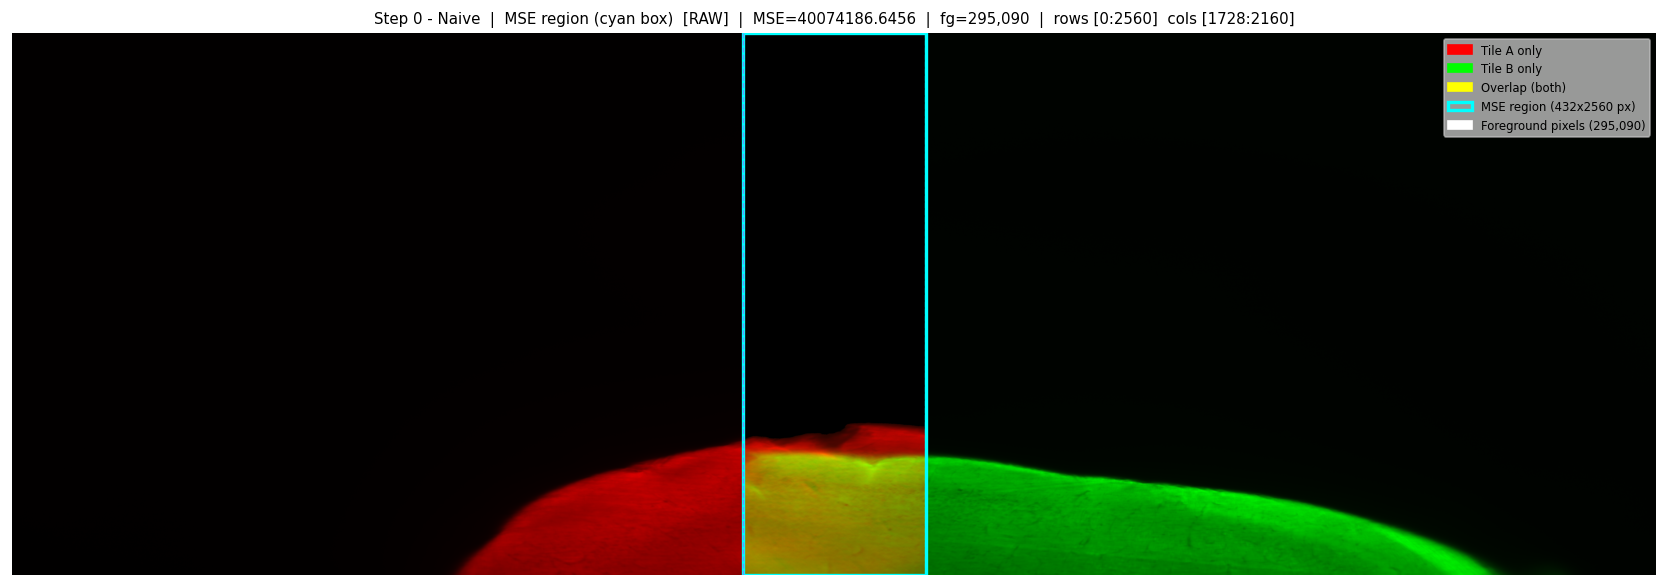

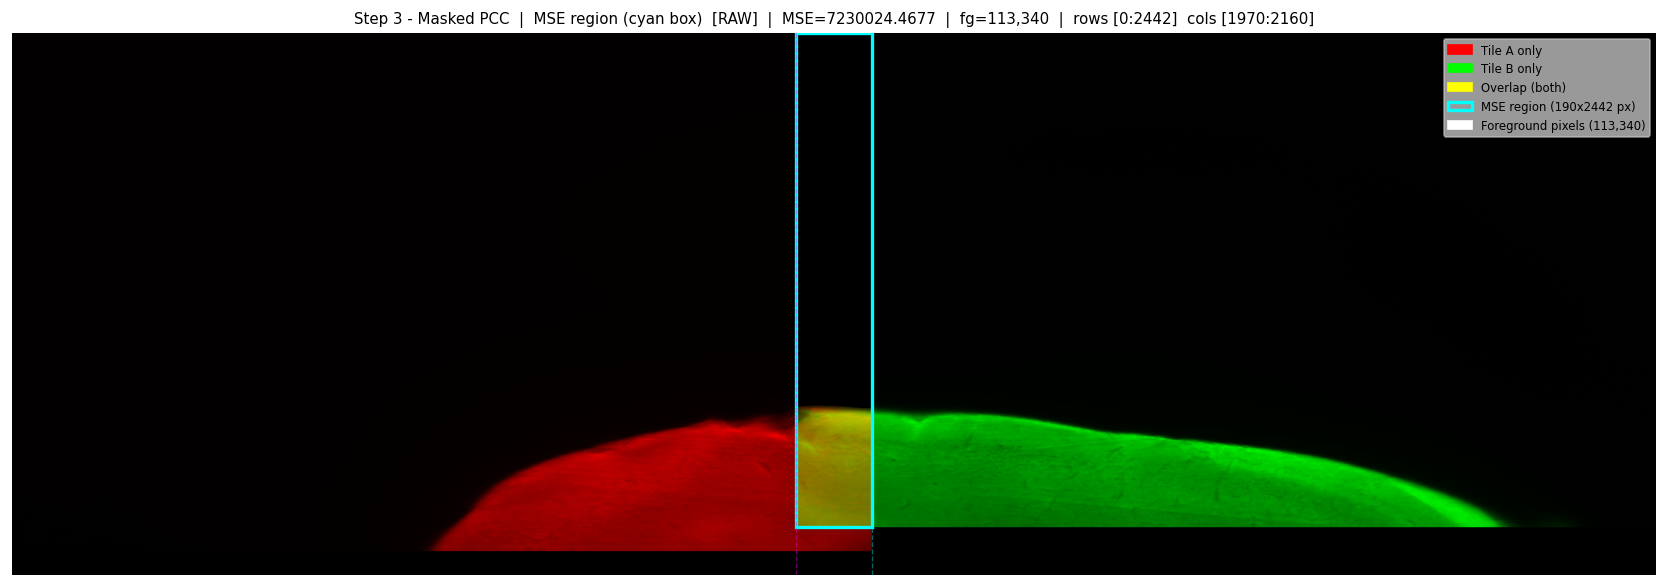

In [147]:
# -- MSE Evaluation [RAW] -----------------------------------------
# Width:  left edge of img_b on canvas --> right edge of img_a on canvas
# Height: dy > 0: top of A --> bottom of B
#         dy < 0: top of B --> bottom of A
res_raw = compute_mse_patches(
    img_a_eval=img_a, img_b_eval=img_b,
    img_a_raw=img_a, img_b_raw=img_b,
    overlap_px_naive=overlap_px_naive,
    overlap_px_pcc=overlap_px_pcc,
    dy=dy3raw, dx=dx3raw,
    otsu_multiplier=OTSU_MULTIPLIER,
)

print_mse_table(res_raw, dy=dy3raw, otsu_multiplier=OTSU_MULTIPLIER, label='RAW pixel MSE')

visualise_mse_region(
    img_a, img_b, img_a, img_b,
    overlap_px=overlap_px_naive, dy=0.0, dx=0.0,
    row_start=res_raw['rs0'], row_end=res_raw['re0'],
    col_start=res_raw['cs0'], col_end=res_raw['ce0'],
    mse=res_raw['mse0'], n_fg=res_raw['nfg0'],
    otsu_multiplier=OTSU_MULTIPLIER,
    title='Step 0 - Naive  |  MSE region (cyan box)  [RAW]',
)

visualise_mse_region(
    img_a, img_b, img_a, img_b,
    overlap_px=overlap_px_pcc, dy=dy3raw, dx=dx3raw,
    row_start=res_raw['rs3'], row_end=res_raw['re3'],
    col_start=res_raw['cs3'], col_end=res_raw['ce3'],
    mse=res_raw['mse3'], n_fg=res_raw['nfg3'],
    otsu_multiplier=OTSU_MULTIPLIER,
    title='Step 3 - Masked PCC  |  MSE region (cyan box)  [RAW]',
)


---
## Part 2 - Z-Score Normalized Pixel Values

Pixel values are Z-score normalized per tile before PCC and MSE.
Raw images are still used for stitching, display, and Otsu foreground masking.

### Step 0 - Naive stitch (no registration) [NORM]

Stitched canvas: (2560, 3888)


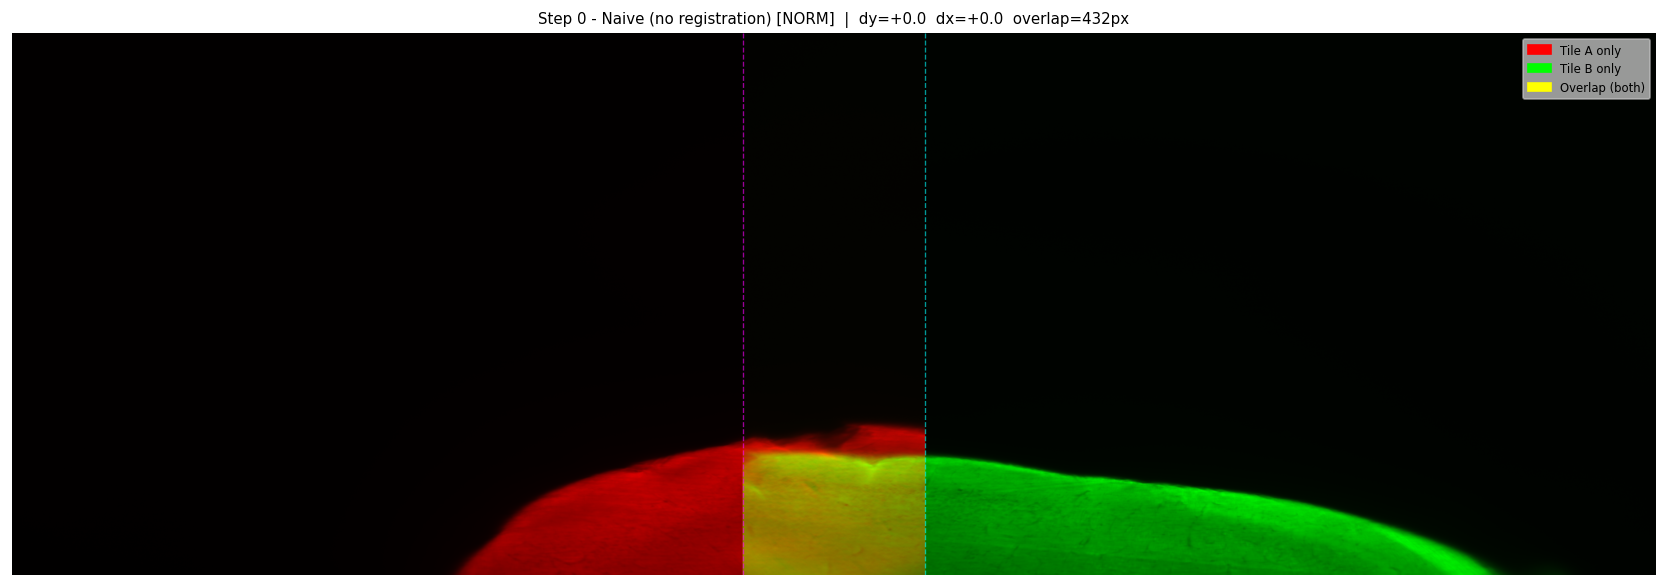

  Shift: dy=+0.00, dx=+0.00


In [148]:
# -- Step 0 (NORM): Naive stitch ----------------------------------
result_naive = stitch_horizontal(img_a, img_b, overlap_px_naive)
print(f'Stitched canvas: {result_naive.shape}')
overlay_rgy(img_a, img_b, overlap_px_naive, dy=0.0, dx=0.0,
            title='Step 0 - Naive (no registration) [NORM]')


### Step 1 - PCC on full normalized frames [NORM]

Full-frame PCC (NORM)  -->  dy=+0.00  dx=-1049.15  error=0.7725


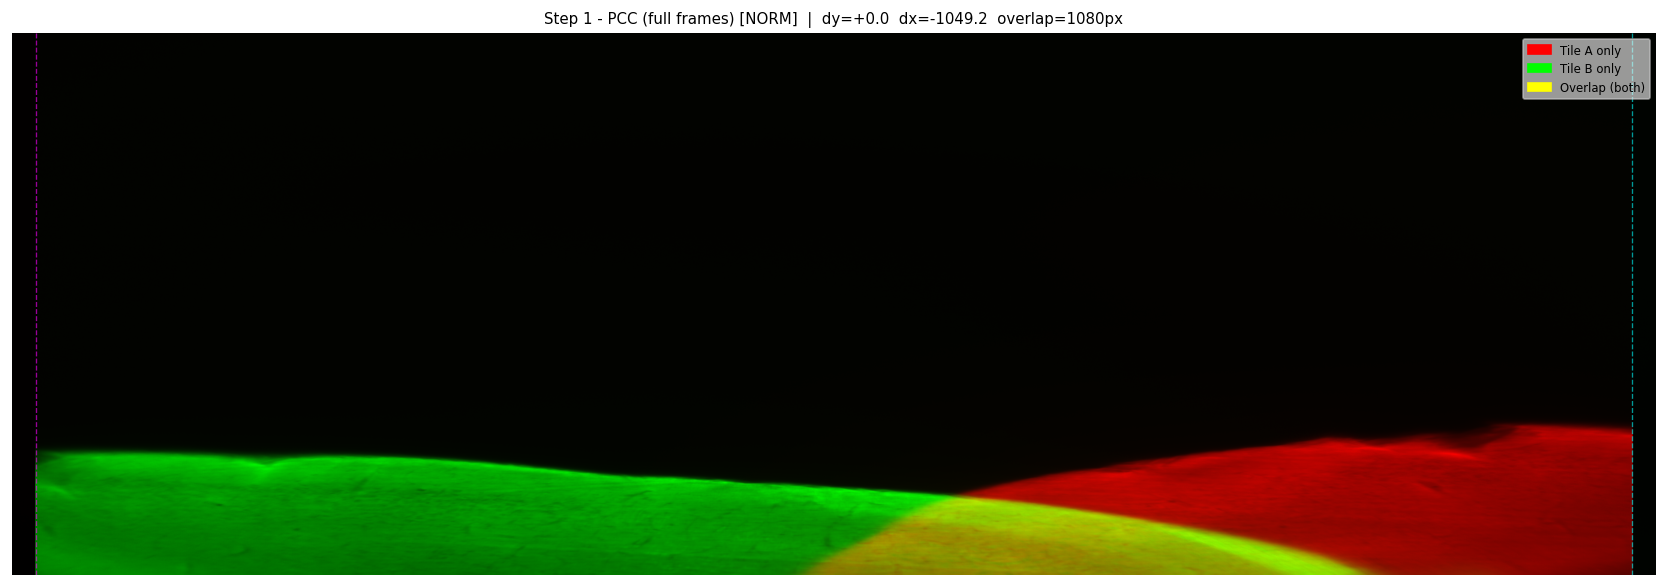

  Shift: dy=+0.00, dx=-1049.15


In [149]:
# -- Step 1 (NORM): PCC on full frames -----------------------------
dy1norm, dx1norm, err1norm = run_pcc(img_a_norm, img_b_norm, upsample=UPSAMPLE)
print(f'Full-frame PCC (NORM)  -->  dy={dy1norm:+.2f}  dx={dx1norm:+.2f}  error={err1norm:.4f}')
overlay_rgy(img_a, img_b, overlap_px_pcc, dy=dy1norm, dx=dx1norm,
            title='Step 1 - PCC (full frames) [NORM]')


### Step 2 - PCC on normalized overlap strips [NORM]

Overlap-strip PCC (NORM)  -->  dy=-0.20  dx=+400.75  error=0.5154


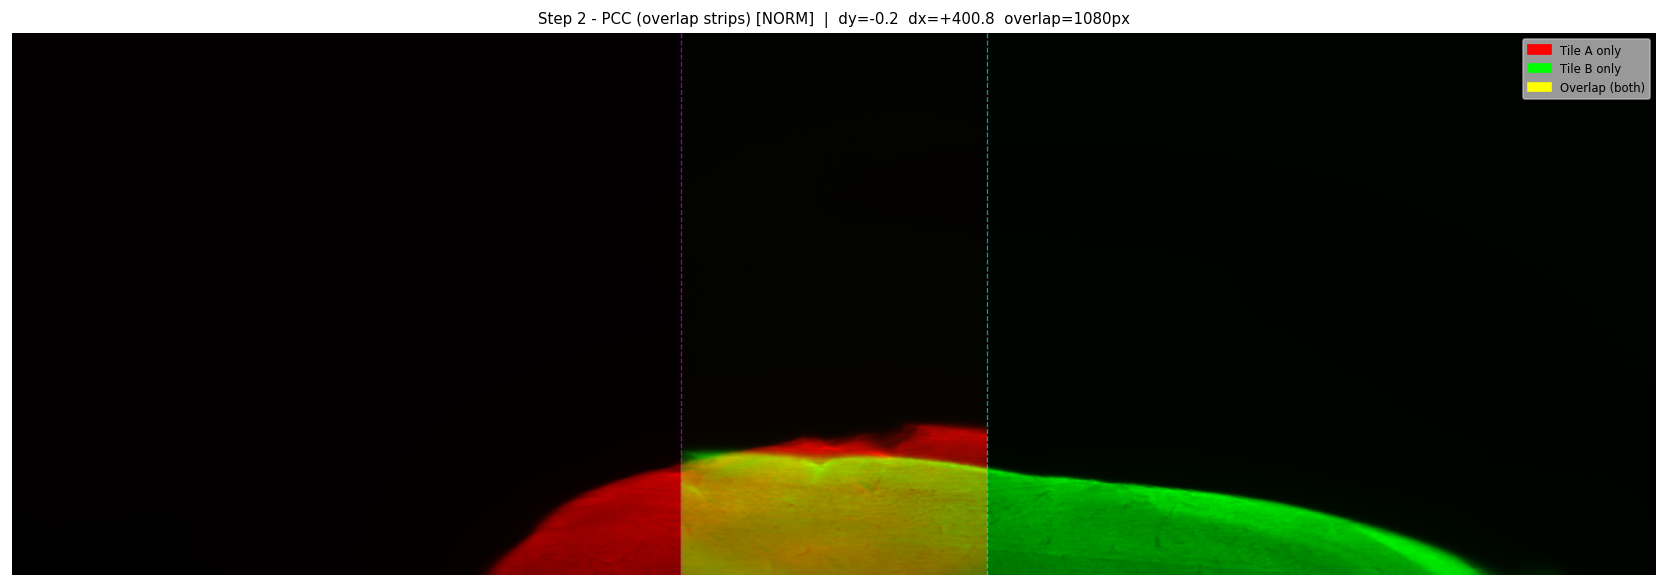

  Shift: dy=-0.20, dx=+400.75


In [150]:
# -- Step 2 (NORM): PCC on overlap strips --------------------------
strip_a2norm = img_a_norm[:, -overlap_px_pcc:]
strip_b2norm = img_b_norm[:,  :overlap_px_pcc]
dy2norm, dx2norm, err2norm = run_pcc(strip_a2norm, strip_b2norm, upsample=UPSAMPLE)
print(f'Overlap-strip PCC (NORM)  -->  dy={dy2norm:+.2f}  dx={dx2norm:+.2f}  error={err2norm:.4f}')
overlay_rgy(img_a, img_b, overlap_px_pcc, dy=dy2norm, dx=dx2norm,
            title='Step 2 - PCC (overlap strips) [NORM]')


### Step 3 - PCC on Otsu-masked normalized overlap strips [NORM]

Normalized strips supplied to PCC; Otsu thresholds computed on raw strips.

Otsu(A strip) = 7775.51  -->  threshold = 3887.75
Otsu(B strip) = 6301.40  -->  threshold = 3150.70
Foreground coverage: A=21.2%  B=20.7%


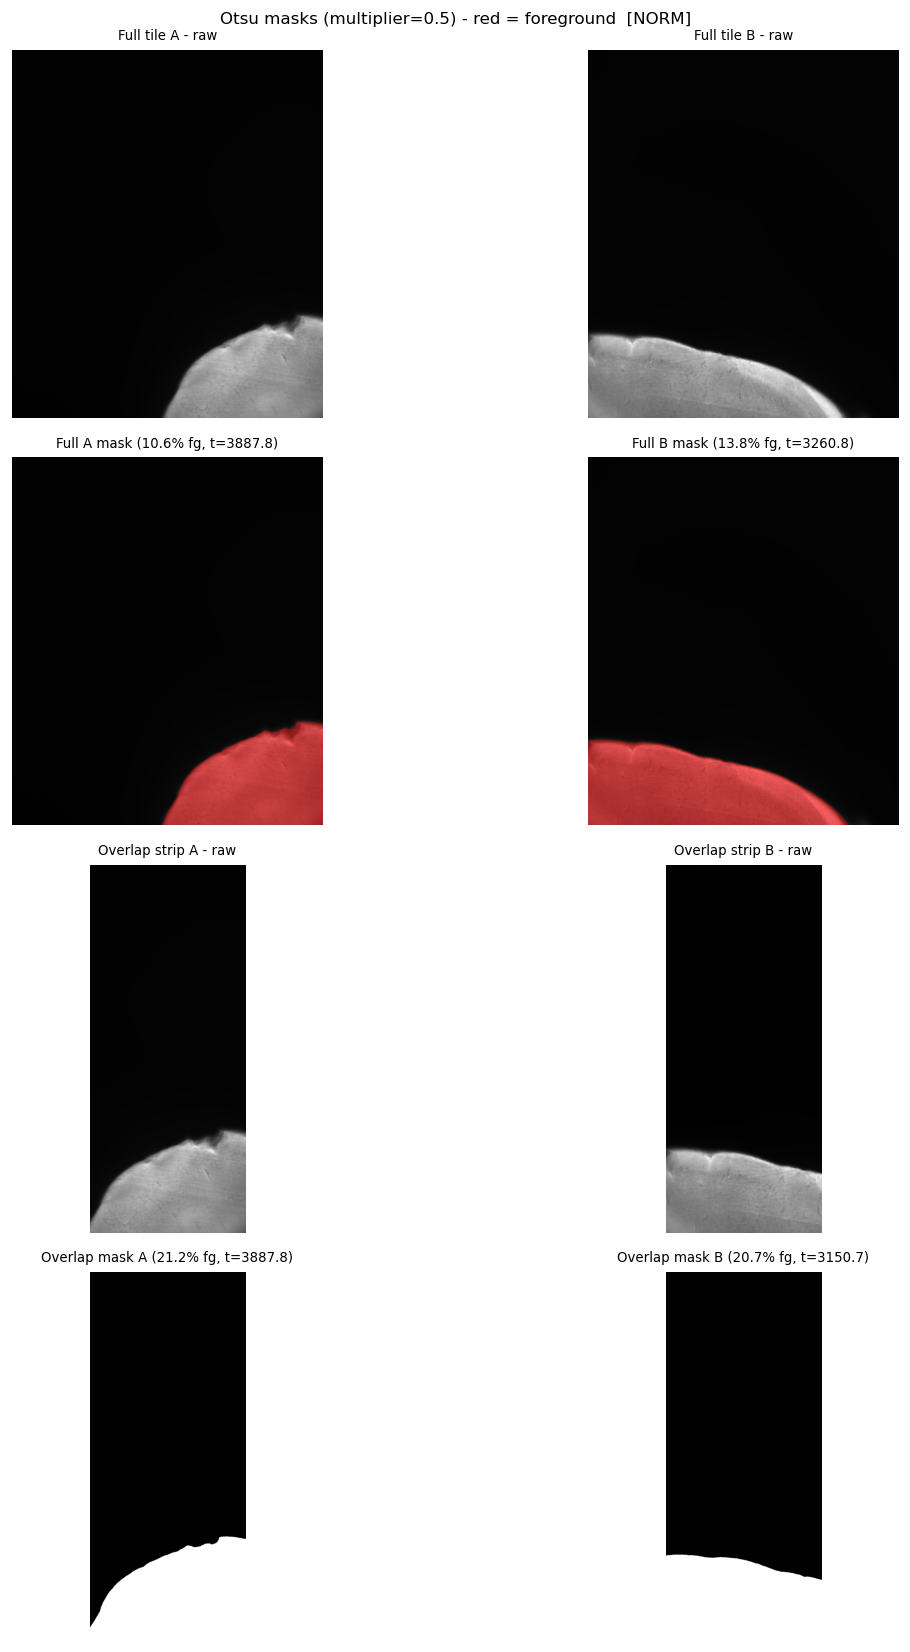

Masked PCC (NORM)  -->  dy=-118.00  dx=+890.00  error=nan


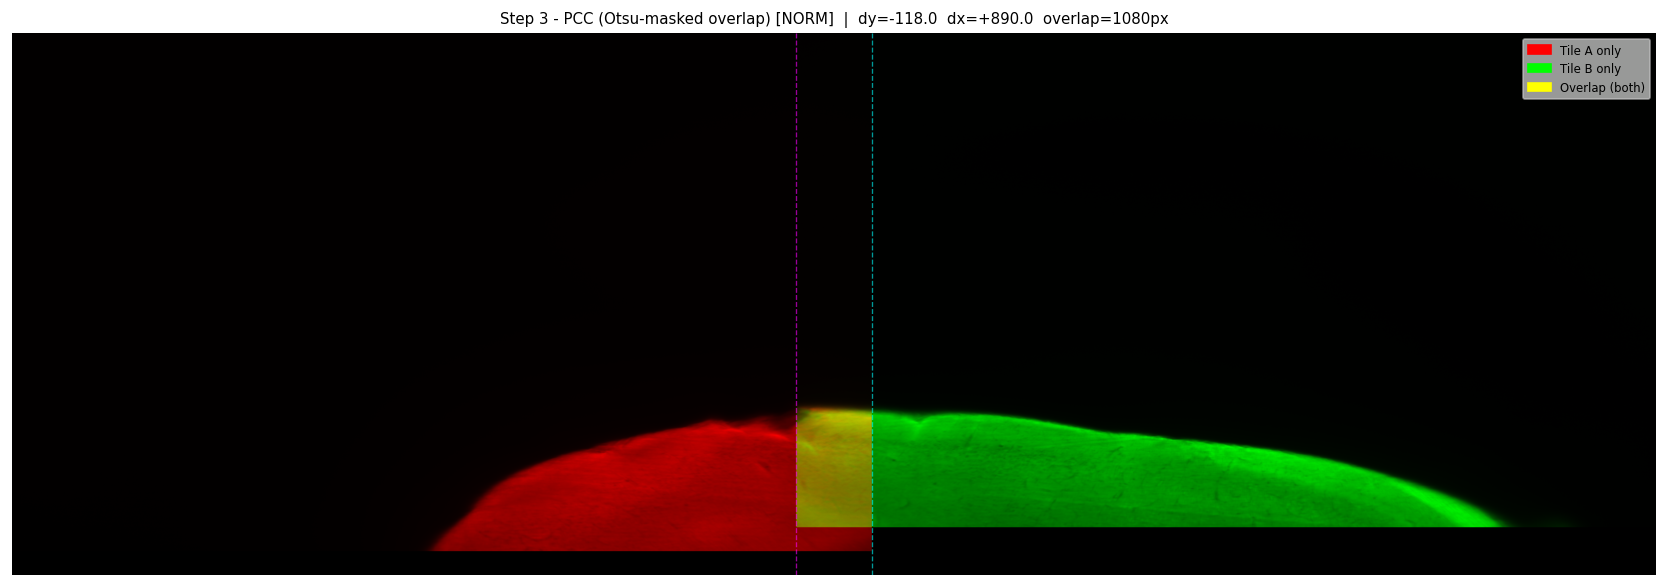

  Shift: dy=-118.00, dx=+890.00


In [151]:
# -- Step 3 (NORM): Otsu-masked PCC --------------------------------
sa3norm = img_a_norm[:, -overlap_px_pcc:].copy()
sb3norm = img_b_norm[:,  :overlap_px_pcc].copy()
sa3rnorm = img_a[:, -overlap_px_pcc:].copy()
sb3rnorm = img_b[:,  :overlap_px_pcc].copy()

oanorm = threshold_otsu(sa3rnorm); obnorm = threshold_otsu(sb3rnorm)
tanorm = OTSU_MULTIPLIER * oanorm;  tbnorm = OTSU_MULTIPLIER * obnorm
print(f'Otsu(A strip) = {oanorm:.2f}  -->  threshold = {tanorm:.2f}')
print(f'Otsu(B strip) = {obnorm:.2f}  -->  threshold = {tbnorm:.2f}')

ma3norm = sa3rnorm > tanorm
mb3norm = sb3rnorm > tbnorm
print(f'Foreground coverage: A={100*ma3norm.mean():.1f}%  B={100*mb3norm.mean():.1f}%')

def make_mask_overlay(img, mask):
    g = norm_disp(img)
    rgb = np.stack([g, g, g], axis=-1)
    rgb[mask, 0] = np.clip(g[mask] * 0.6 + 0.4, 0, 1)
    rgb[mask, 1] = g[mask] * 0.4
    rgb[mask, 2] = g[mask] * 0.4
    return rgb

ft_anorm = OTSU_MULTIPLIER * threshold_otsu(img_a)
ft_bnorm = OTSU_MULTIPLIER * threshold_otsu(img_b)
fm_anorm = img_a > ft_anorm; fm_bnorm = img_b > ft_bnorm

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes[0,0].imshow(norm_disp(img_a), cmap='gray'); axes[0,0].set_title('Full tile A - raw', fontsize=8); axes[0,0].axis('off')
axes[0,1].imshow(norm_disp(img_b), cmap='gray'); axes[0,1].set_title('Full tile B - raw', fontsize=8); axes[0,1].axis('off')
axes[1,0].imshow(make_mask_overlay(img_a, fm_anorm)); axes[1,0].set_title(f'Full A mask ({100*fm_anorm.mean():.1f}% fg, t={ft_anorm:.1f})', fontsize=8); axes[1,0].axis('off')
axes[1,1].imshow(make_mask_overlay(img_b, fm_bnorm)); axes[1,1].set_title(f'Full B mask ({100*fm_bnorm.mean():.1f}% fg, t={ft_bnorm:.1f})', fontsize=8); axes[1,1].axis('off')
axes[2,0].imshow(norm_disp(sa3rnorm), cmap='gray'); axes[2,0].set_title('Overlap strip A - raw', fontsize=8); axes[2,0].axis('off')
axes[2,1].imshow(norm_disp(sb3rnorm), cmap='gray'); axes[2,1].set_title('Overlap strip B - raw', fontsize=8); axes[2,1].axis('off')
axes[3,0].imshow(ma3norm.astype('uint8'), cmap='gray', vmin=0, vmax=1); axes[3,0].set_title(f'Overlap mask A ({100*ma3norm.mean():.1f}% fg, t={tanorm:.1f})', fontsize=8); axes[3,0].axis('off')
axes[3,1].imshow(mb3norm.astype('uint8'), cmap='gray', vmin=0, vmax=1); axes[3,1].set_title(f'Overlap mask B ({100*mb3norm.mean():.1f}% fg, t={tbnorm:.1f})', fontsize=8); axes[3,1].axis('off')
plt.suptitle(f'Otsu masks (multiplier={OTSU_MULTIPLIER}) - red = foreground  [NORM]', fontsize=10)
plt.tight_layout(); plt.show()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    shift, err3norm, _ = phase_cross_correlation(
        sa3norm, sb3norm,
        reference_mask=ma3norm, moving_mask=mb3norm, overlap_ratio=0.1)
dy3norm, dx3norm = float(shift[0]), float(shift[1])
print(f'Masked PCC (NORM)  -->  dy={dy3norm:+.2f}  dx={dx3norm:+.2f}  error={err3norm}')
overlay_rgy(img_a, img_b, overlap_px_pcc, dy=dy3norm, dx=dx3norm,
            title='Step 3 - PCC (Otsu-masked overlap) [NORM]')


### Summary [NORM]

In [152]:
# -- Summary table (NORM) ------------------------------------------
rows_norm = [
    ('Step 0', 'Naive',                0.0,      0.0,      None),
    ('Step 1', 'PCC - full frames',    dy1norm,  dx1norm,  err1norm),
    ('Step 2', 'PCC - overlap strips', dy2norm,  dx2norm,  err2norm),
    ('Step 3', 'PCC - masked overlap', dy3norm,  dx3norm,  err3norm),
]
print(f"{'Step':<8} {'Method':<30} {'dy':>8} {'dx':>8} {'PCC err':>10}")
print('-' * 68)
for step, method, dy, dx, err in rows_norm:
    err_str = f'{err:.4f}' if err is not None else '  -'
    print(f'{step:<8} {method:<30} {dy:>+8.2f} {dx:>+8.2f} {err_str:>10}')


Step     Method                               dy       dx    PCC err
--------------------------------------------------------------------
Step 0   Naive                             +0.00    +0.00          -
Step 1   PCC - full frames                 +0.00 -1049.15     0.7725
Step 2   PCC - overlap strips              -0.20  +400.75     0.5154
Step 3   PCC - masked overlap            -118.00  +890.00        nan


### MSE Evaluation [NORM]

MSE computed on Z-score normalized intensities; foreground masks use raw values.

> MSE ~0 means nearly identical structure; MSE ~2 means ~1 std-dev average disagreement per pixel.

────────────────────────────────────────────────────────────────────────────────
  NORM pixel MSE
  Step 0 strip : cols [1728:2160]  rows [0:2560]
  Step 3 strip : cols [1970:2160]  rows [0:2442]  (190 px wide, dy=-118.00)
  Otsu multiplier : 0.5  |  OR foreground mask

  Method                        Patch shape    FG pixels            MSE    MI (nats)
  --------------------------------------------------------------------------------
  Step 0 - Naive                (2560, 432)      295,090         1.8612       0.2946
  Step 3 - Masked PCC           (2442, 190)      113,340         0.2758       0.5538
  --------------------------------------------------------------------------------
  MSE % change (Step 3 vs Step 0): -85.2%  (improvement)
  MI  % change (Step 3 vs Step 0): +88.0%  (improvement)



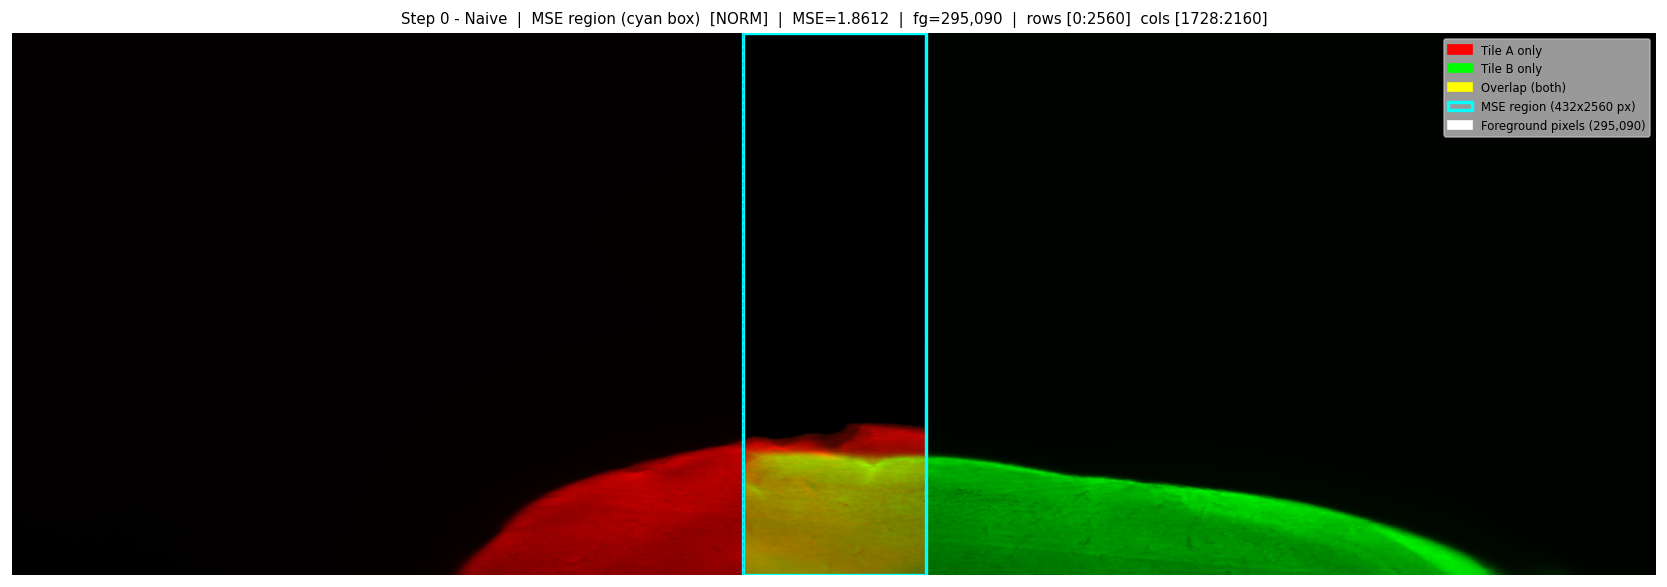

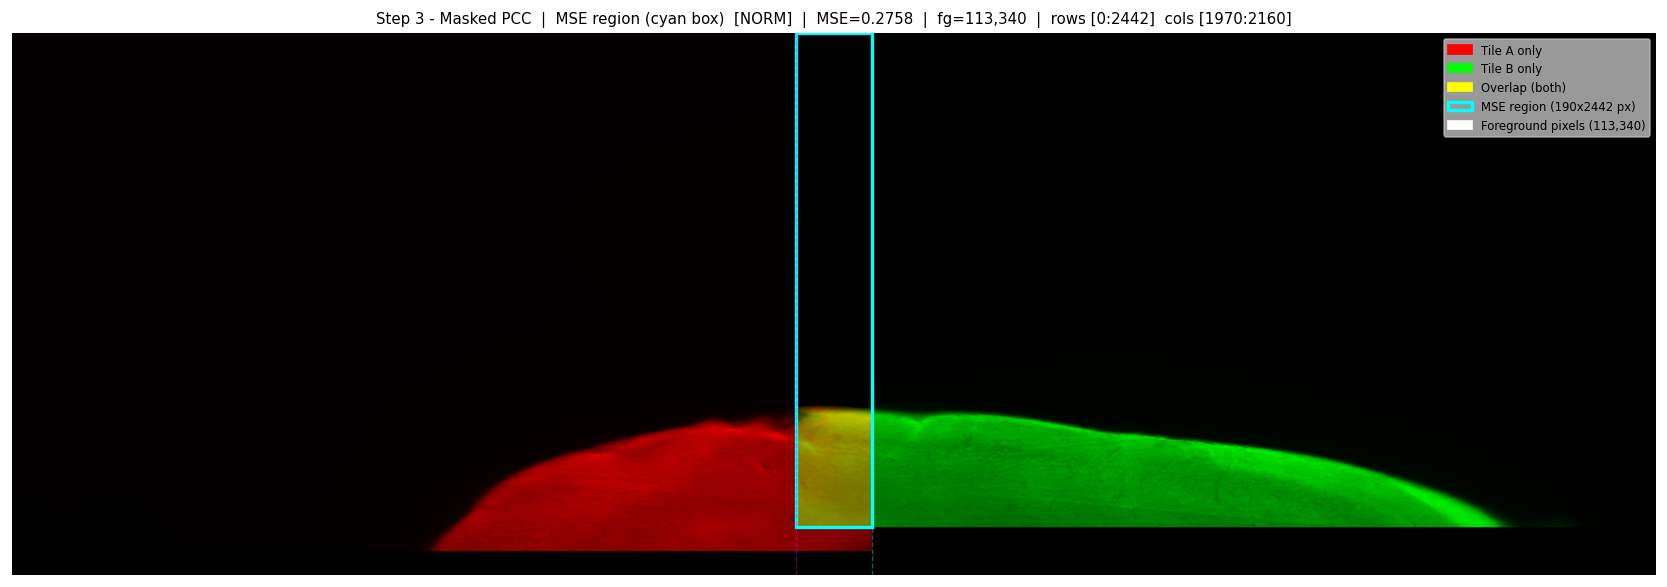

In [153]:
# -- MSE Evaluation [NORM] -----------------------------------------
# Width:  left edge of img_b on canvas --> right edge of img_a on canvas
# Height: dy > 0: top of A --> bottom of B
#         dy < 0: top of B --> bottom of A
res_norm = compute_mse_patches(
    img_a_eval=img_a_norm, img_b_eval=img_b_norm,
    img_a_raw=img_a, img_b_raw=img_b,
    overlap_px_naive=overlap_px_naive,
    overlap_px_pcc=overlap_px_pcc,
    dy=dy3norm, dx=dx3norm,
    otsu_multiplier=OTSU_MULTIPLIER,
)

print_mse_table(res_norm, dy=dy3norm, otsu_multiplier=OTSU_MULTIPLIER, label='NORM pixel MSE')

visualise_mse_region(
    img_a, img_b, img_a, img_b,
    overlap_px=overlap_px_naive, dy=0.0, dx=0.0,
    row_start=res_norm['rs0'], row_end=res_norm['re0'],
    col_start=res_norm['cs0'], col_end=res_norm['ce0'],
    mse=res_norm['mse0'], n_fg=res_norm['nfg0'],
    otsu_multiplier=OTSU_MULTIPLIER,
    title='Step 0 - Naive  |  MSE region (cyan box)  [NORM]',
)

visualise_mse_region(
    img_a, img_b, img_a, img_b,
    overlap_px=overlap_px_pcc, dy=dy3norm, dx=dx3norm,
    row_start=res_norm['rs3'], row_end=res_norm['re3'],
    col_start=res_norm['cs3'], col_end=res_norm['ce3'],
    mse=res_norm['mse3'], n_fg=res_norm['nfg3'],
    otsu_multiplier=OTSU_MULTIPLIER,
    title='Step 3 - Masked PCC  |  MSE region (cyan box)  [NORM]',
)


---
## Final Comparison - Raw vs Normalized MSE

In [154]:
# -- Final comparison: Raw vs Normalized MSE + MI ------------------
def pct(a, b): return 100.0 * (b - a) / a if a else float('nan')

print('=' * 90)
print('FINAL COMPARISON - Raw vs Normalized  |  MSE (lower=better)  &  MI (higher=better)')
print('=' * 90)
print(f"{'Evaluation':<30} {'Step0 MSE':>10} {'Step3 MSE':>10} {'MSE%':>8}  "
      f"{'Step0 MI':>10} {'Step3 MI':>10} {'MI%':>8}")
print('-' * 90)
print(f"{'RAW pixel values':<30} "
      f"{res_raw['mse0']:>10.4f} {res_raw['mse3']:>10.4f} {pct(res_raw['mse0'], res_raw['mse3']):>+7.1f}%  "
      f"{res_raw['mi0']:>10.4f} {res_raw['mi3']:>10.4f} {pct(res_raw['mi0'], res_raw['mi3']):>+7.1f}%")
print(f"{'Z-score normalized':<30} "
      f"{res_norm['mse0']:>10.4f} {res_norm['mse3']:>10.4f} {pct(res_norm['mse0'], res_norm['mse3']):>+7.1f}%  "
      f"{res_norm['mi0']:>10.4f} {res_norm['mi3']:>10.4f} {pct(res_norm['mi0'], res_norm['mi3']):>+7.1f}%")
print('=' * 90)
print('  MSE: negative % = improvement  |  MI: positive % = improvement')


FINAL COMPARISON - Raw vs Normalized  |  MSE (lower=better)  &  MI (higher=better)
Evaluation                      Step0 MSE  Step3 MSE     MSE%    Step0 MI   Step3 MI      MI%
------------------------------------------------------------------------------------------
RAW pixel values               40074186.6456 7230024.4677   -82.0%      0.2946     0.5538   +88.0%
Z-score normalized                 1.8612     0.2758   -85.2%      0.2946     0.5538   +88.0%
  MSE: negative % = improvement  |  MI: positive % = improvement
